In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import gropt
from helper_utils import *
import gropt
from gropt_diffusion import *
from trap_diffusion3 import *
import pypulseq as pp
import os

# Demo on How Stimulation Thresholds Configuration

In [12]:
main_path = '../Sequence_Code/'
timing_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls.mat'
waveform_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls_waveforms.mat'
dt = 1e-5 #200e-6

TE_demo = 50.1e-3

In [13]:
# Load ASC file and make SAFE params

# All Asc file locations 
asc_file_name = ['/Users/ariel/Desktop/MP_GradSys_P034_X60.asc',
              '/Users/ariel/Documents/PhD/Projects/asc_files/MP_GradSys_K2309_2250V_951A_XQ_GC04XQ.asc',
              '/Users/ariel/Downloads/MP_GPA_K2309_2250V_793A_GC99 (1).asc']

idx_asc = 0

[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name[idx_asc])
print(safe_params)


{'tau1': array([0.0008, 0.0008, 0.0008]), 'tau2': array([0.012, 0.012, 0.012]), 'tau3': array([0.000212, 0.000194, 0.000184]), 'a1': array([0.297, 0.213, 0.275]), 'a2': array([0.5, 0.5, 0.5]), 'a3': array([0.203, 0.287, 0.225]), 'stim_limit': array([34.725, 23.202, 31.168]), 'g_scale': array([0.3324, 0.3369, 0.3059])}


In [14]:
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# UTILITY FUNCTIONS
# --------------------------------------------------------------

def interp_lin(t, g, tt):
    """Safe linear interpolation."""
    if t.size == 0 or g.size == 0:
        return np.zeros_like(tt)
    f = interp1d(t, g, kind='linear', fill_value=0, bounds_error=False)
    return f(tt)

def time_to_index(t, t_ref):
    """Nearest index to a reference time."""
    return int(np.argmin(np.abs(t - t_ref)))

def resample_to_raster(t_old, y_old, raster):
    """Resample y_old(t_old) onto a new uniform time axis."""
    t_new = np.arange(t_old[0], t_old[-1], raster)
    y_new = np.interp(t_new, t_old, y_old)
    return t_new, y_new

# ==============================================================
# MAIN CLASS
# ==============================================================

class PNSCNS_SequenceBuilder:
    """
    Build interpolated waveforms, repeated sequences, compute PNS/CNS responses,
    truncate from 90° RF center to end of zeros_delayTE2, and resample.
    Includes optional fat-sat block before RF90.
    """

    def __init__(self, timing_file, waveform_file,
                 dt_in, dt_out, safe_params, safe_params_cardiac, TE, n_repeats=5):

        self.timing_file  = timing_file
        self.waveform_file = waveform_file
        self.dt_in   = dt_in
        self.dt_out  = dt_out
        self.safe_params = safe_params
        self.safe_params_cardiac = safe_params_cardiac
        self.TE = TE
        self.n_repeats = n_repeats

        # -----------------------------
        # Load data and interpolate
        # -----------------------------
        self._load_timing()
        self._load_waveforms()
        self._interpolate_RF_blocks()
        self._build_diffusion_encoding()
        self._assemble_sequence()
        
        # -----------------------------
        # Repeat sequence and compute SAFE/CNS
        # -----------------------------
        self._repeat_sequence()
        self._compute_safe()

        # -----------------------------
        # Truncate 90° center → end of zeros_delayTE2
        # -----------------------------
        self._truncate_center90_to_TE2()

        # -----------------------------
        # Resample SAFE/PNS & CNS
        # -----------------------------
        self._resample_safe_cns()


    # ----------------------------------------------------------
    # Load timing file
    # ----------------------------------------------------------
    def _load_timing(self):
        data = loadmat(self.timing_file)

        self.rf90_dur   = data['rf_90_duration'][0][0]
        self.rf180_dur  = data['rf_180_duration'][0][0]
        self.center90   = data['rf_90_rfCenterInclDelay'][0][0]
        self.center180  = data['rf_180_rfCenterInclDelay'][0][0]
        self.nav_dur    = data['nav_dur'][0][0]
        self.timeToTE   = data['timeToTE'][0][0]
        self.T90        = (self.rf90_dur - self.center90 + self.nav_dur)
        self.T180       = self.rf180_dur
        self.sys = data['sys']  # optional


    # ----------------------------------------------------------
    # Load waveform file (including optional fatsat)
    # ----------------------------------------------------------
    def _load_waveforms(self):
        mat = loadmat(self.waveform_file)
        self.w90   = mat["wave_data_rf90"]
        self.w180  = mat["wave_data_rf180"]
        self.wEPI  = mat["wave_data_epi"]
        self.wFAT  = mat.get("wave_data_fatsat", None)  # optional fatsat block


    # ----------------------------------------------------------
    # Extract and interpolate RF/EPI/FAT blocks
    # ----------------------------------------------------------
    def _extract(self, W):
        t_x, gx = W[0,0][0,:], W[0,0][1,:]
        t_y, gy = W[0,1][0,:], W[0,1][1,:]
        t_z, gz = W[0,2][0,:], W[0,2][1,:]
        t_rf, rf = W[0,3][0,:], W[0,3][1,:]

        gx = pp.convert.convert(gx, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
        gy = pp.convert.convert(gy, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3
        gz = pp.convert.convert(gz, from_unit = 'Hz/m', to_unit='mT/m') * 1e-3

        if rf.size > 0:
            rf = np.abs(rf)/np.max(np.abs(rf))

        return dict(t_x=t_x, gx=gx,
                    t_y=t_y, gy=gy,
                    t_z=t_z, gz=gz,
                    t_rf=t_rf, rf=rf)

    def _interpolate_block(self, block, duration):
        tt = np.arange(0, duration + self.dt_in, self.dt_in)
        gx = interp_lin(block["t_x"], block["gx"], tt)
        gy = interp_lin(block["t_y"], block["gy"], tt)
        gz = interp_lin(block["t_z"], block["gz"], tt)
        rf = interp_lin(block["t_rf"], block["rf"], tt)
        return dict(gx=gx, gy=gy, gz=gz, rf=rf, t=tt)

    def _interpolate_RF_blocks(self):
        self.RF90_raw  = self._extract(self.w90)
        self.RF180_raw = self._extract(self.w180)
        self.EPI_raw   = self._extract(self.wEPI)

        self.RF90_interp  = self._interpolate_block(self.RF90_raw,  self.rf90_dur)
        self.RF180_interp = self._interpolate_block(self.RF180_raw, self.rf180_dur)

        # Interpolate fatsat if available
        if self.wFAT is not None:
            t_arrays = [self.wFAT[0,0][0,:], self.wFAT[0,1][0,:],
                        self.wFAT[0,2][0,:], self.wFAT[0,3][0,:]]
            dur_fat = max([t.max() for t in t_arrays if t.size>0])
            self.FAT_interp = self._interpolate_block(self._extract(self.wFAT), dur_fat)
        else:
            self.FAT_interp = dict(gx=np.array([]), gy=np.array([]), gz=np.array([]), rf=np.array([]), t=np.array([]))

        # EPI flexible
        t_arrays = [self.EPI_raw["t_x"], self.EPI_raw["t_y"], self.EPI_raw["t_z"], self.EPI_raw["t_rf"]]
        tmax = max([t.max() for t in t_arrays if t.size>0])
        tt = np.arange(0, tmax + self.dt_in, self.dt_in)
        self.EPI_interp = dict(
            gx=interp_lin(self.EPI_raw["t_x"], self.EPI_raw["gx"], tt),
            gy=interp_lin(self.EPI_raw["t_y"], self.EPI_raw["gy"], tt),
            gz=interp_lin(self.EPI_raw["t_z"], self.EPI_raw["gz"], tt),
            rf=interp_lin(self.EPI_raw["t_rf"], self.EPI_raw["rf"], tt),
            t=tt
        )


    # ----------------------------------------------------------
    # Split RF180 into pre/post, create delays
    # ----------------------------------------------------------
    def _build_diffusion_encoding(self):
        self.i_center_90  = time_to_index(self.RF90_interp["t"],  self.center90)
        self.i_center_180 = time_to_index(self.RF180_interp["t"], self.center180)

        R = self.RF180_interp
        self.RF180_pre  = {k:R[k][:self.i_center_180+1] for k in ["gx","gy","gz","rf"]}
        self.RF180_post = {k:R[k][self.i_center_180:]   for k in ["gx","gy","gz","rf"]}

        dt = self.dt_in
        delayTE1 = np.ceil((self.TE/2 - self.T90 - self.center180)/dt)*dt
        delayTE2 = np.ceil((self.TE/2 - self.T180 + self.center180 - self.timeToTE)/dt)*dt

        self.z1 = np.zeros(int(delayTE1/dt))
        self.z2 = np.zeros(int(delayTE2/dt))


    # ----------------------------------------------------------
    # Assemble sequence (one repetition)
    # ----------------------------------------------------------
    # ----------------------------------------------------------
    # Assemble sequence (one repetition)
    # ----------------------------------------------------------
    def _assemble_sequence(self):
        def cat(keys): return np.concatenate(keys)
        self.Gx_seq = cat([
            self.FAT_interp["gx"],    # Fat-sat
            self.RF90_interp["gx"],   # 90° RF
            self.z1,                  # delayTE1
            self.RF180_interp["gx"],  # Full RF180
            self.z2,                  # delayTE2
            self.EPI_interp["gx"]     # EPI readout
        ])
        self.Gy_seq = cat([
            self.FAT_interp["gy"],
            self.RF90_interp["gy"],
            self.z1,
            self.RF180_interp["gy"],
            self.z2,
            self.EPI_interp["gy"]
        ])
        self.Gz_seq = cat([
            self.FAT_interp["gz"],
            self.RF90_interp["gz"],
            self.z1,
            self.RF180_interp["gz"],
            self.z2,
            self.EPI_interp["gz"]
        ])
        self.RF_seq = cat([
            self.FAT_interp["rf"] * 0.25,
            self.RF90_interp["rf"] * 0.75,
            self.z1,
            self.RF180_interp["rf"],
            self.z2,
            self.EPI_interp["rf"]
        ])
        n = len(self.Gx_seq)
        self.t_seq = np.arange(0, n*self.dt_in, self.dt_in)


    # ----------------------------------------------------------
    # Repeat sequence and store full repeated arrays
    # ----------------------------------------------------------
    def _repeat_sequence(self):
        n = self.n_repeats
        self.Gx_seq_full = np.tile(self.Gx_seq, n)
        self.Gy_seq_full = np.tile(self.Gy_seq, n)
        self.Gz_seq_full = np.tile(self.Gz_seq, n)
        self.RF_seq_full = np.tile(self.RF_seq, n)
        self.t_seq_full  = np.tile(self.t_seq, n)


    # ----------------------------------------------------------
    # Compute SAFE / CNS using gropt wrapper
    # ----------------------------------------------------------
    def _compute_safe(self):
        import gropt.gropt_wrapper as gw

        dt = self.dt_in
        self.safe_gx = np.array(gw.get_SAFE(self.Gx_seq_full, dt, safe_params=self.safe_params, new_first_axis=0))
        self.safe_gy = np.array(gw.get_SAFE(self.Gy_seq_full, dt, safe_params=self.safe_params, new_first_axis=1))
        self.safe_gz = np.array(gw.get_SAFE(self.Gz_seq_full, dt, safe_params=self.safe_params, new_first_axis=2))

        self.safe_cardiac_gx = np.array(gw.get_SAFE(self.Gx_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=0))
        self.safe_cardiac_gy = np.array(gw.get_SAFE(self.Gy_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=1))
        self.safe_cardiac_gz = np.array(gw.get_SAFE(self.Gz_seq_full, dt, safe_params=self.safe_params_cardiac, new_first_axis=2))


    # ----------------------------------------------------------
    # Truncate from RF90 center → end of zeros_delayTE2
    # ----------------------------------------------------------
    # ----------------------------------------------------------
    # Truncate from RF90 center → end of sequence (including EPI)
    # ----------------------------------------------------------
    def _truncate_center90_to_TE2(self):
        # Indices of sequence components
        len_FAT     = len(self.FAT_interp["rf"])
        len_RF90    = len(self.RF90_interp["rf"])
        len_z1      = len(self.z1)
        len_RF180   = len(self.RF180_interp["rf"])
        len_z2      = len(self.z2)
        len_EPI     = len(self.EPI_interp["rf"])

        # Total length up to end of zeros_delayTE2
        idx_end_TE2 = len_FAT + len_RF90 + len_z1 + len_RF180 + len_z2 #+ len_EPI

        # Index of RF90 center relative to full sequence
        start = len_FAT + self.i_center_90
        end   = idx_end_TE2

        # Truncate sequences
        self.Gx_trunc = self.Gx_seq_full[start:end]
        self.Gy_trunc = self.Gy_seq_full[start:end]
        self.Gz_trunc = self.Gz_seq_full[start:end]
        self.RF_trunc = self.RF_seq_full[start:end]

        # Reset time array so 0 = start of RF90
        self.t_trunc  = self.t_seq_full[start:end] - self.t_seq_full[start]

        # Truncate SAFE/PNS & CNS
        self.safe_gx_trunc = self.safe_gx[start:end]
        self.safe_gy_trunc = self.safe_gy[start:end]
        self.safe_gz_trunc = self.safe_gz[start:end]

        self.safe_cardiac_gx_trunc = self.safe_cardiac_gx[start:end]
        self.safe_cardiac_gy_trunc = self.safe_cardiac_gy[start:end]
        self.safe_cardiac_gz_trunc = self.safe_cardiac_gz[start:end]


    # ----------------------------------------------------------
    # Resample truncated SAFE/PNS & CNS responses to dt_out
    # ----------------------------------------------------------
    def _resample_safe_cns(self):
        dt_out = self.dt_out
        t_old = self.t_trunc

        self.t_out, self.Gx_out = resample_to_raster(t_old, self.Gx_trunc, dt_out)
        _, self.Gy_out = resample_to_raster(t_old, self.Gy_trunc, dt_out)
        _, self.Gz_out = resample_to_raster(t_old, self.Gz_trunc, dt_out)

        _, self.safe_gx_out = resample_to_raster(t_old, self.safe_gx_trunc, dt_out)
        _, self.safe_gy_out = resample_to_raster(t_old, self.safe_gy_trunc, dt_out)
        _, self.safe_gz_out = resample_to_raster(t_old, self.safe_gz_trunc, dt_out)

        _, self.safe_cardiac_gx_out = resample_to_raster(t_old, self.safe_cardiac_gx_trunc, dt_out)
        _, self.safe_cardiac_gy_out = resample_to_raster(t_old, self.safe_cardiac_gy_trunc, dt_out)
        _, self.safe_cardiac_gz_out = resample_to_raster(t_old, self.safe_cardiac_gz_trunc, dt_out)


    # ----------------------------------------------------------
    # Optional plotting function
    # ----------------------------------------------------------
    def plot_all(self):
        fig, axs = plt.subplots(3,1,figsize=(16,12), sharex=True)

        # -----------------------------
        # Top: Gradients
        # -----------------------------
        axs[0].plot(self.t_trunc, self.Gx_trunc, label='Gx')
        axs[0].plot(self.t_trunc, self.Gy_trunc, label='Gy')
        axs[0].plot(self.t_trunc, self.Gz_trunc, label='Gz')
        axs[0].set_ylabel('Gradient (T/m)')
        axs[0].set_title('Truncated Gradients')
        axs[0].legend()
        axs[0].grid(True, alpha=0.3)

        # -----------------------------
        # Middle: SAFE/PNS
        # -----------------------------
        axs[1].plot(self.t_trunc, self.safe_gx_trunc, label='SAFE Gx', color='blue')
        axs[1].plot(self.t_trunc, self.safe_gy_trunc, label='SAFE Gy', color='orange')
        axs[1].plot(self.t_trunc, self.safe_gz_trunc, label='SAFE Gz', color='green')
        axs[1].plot(self.t_trunc, 1 - self.safe_gx_trunc, '--', color='blue', label='1 - SAFE Gx')
        axs[1].plot(self.t_trunc, 1 - self.safe_gy_trunc, '--', color='orange', label='1 - SAFE Gy')
        axs[1].plot(self.t_trunc, 1 - self.safe_gz_trunc, '--', color='green', label='1 - SAFE Gz')
        axs[1].set_ylabel('SAFE (PNS)')
        axs[1].set_title('SAFE (PNS) Response')
        axs[1].legend(ncol=3, fontsize=9)
        axs[1].grid(True, alpha=0.3)

        # -----------------------------
        # Bottom: SAFE-CNS
        # -----------------------------
        axs[2].plot(self.t_trunc, self.safe_cardiac_gx_trunc, label='SAFE-CNS Gx', color='blue')
        axs[2].plot(self.t_trunc, self.safe_cardiac_gy_trunc, label='SAFE-CNS Gy', color='orange')
        axs[2].plot(self.t_trunc, self.safe_cardiac_gz_trunc, label='SAFE-CNS Gz', color='green')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gx_trunc, '--', color='blue', label='1 - SAFE-CNS Gx')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gy_trunc, '--', color='orange', label='1 - SAFE-CNS Gy')
        axs[2].plot(self.t_trunc, 1 - self.safe_cardiac_gz_trunc, '--', color='green', label='1 - SAFE-CNS Gz')
        axs[2].set_xlabel('Time (s)')
        axs[2].set_ylabel('SAFE-CNS')
        axs[2].set_title('Cardiac SAFE-CNS Response')
        axs[2].legend(ncol=3, fontsize=9)
        axs[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


    # ==============================================================
    # Full Sequence Plot
    # ==============================================================
    def plot_full_sequence(self, lw=4.0, fontsize=16):
        import matplotlib.pyplot as plt
        import numpy as np

        # Time axis (ms)
        t = np.arange(len(self.Gx_seq_full)) * self.dt_in * 1e3

        # Normalize RF to [-1, 1]
        RF = self.RF_seq_full.copy()
        if np.max(np.abs(RF)) > 0:
            RF = RF / np.max(np.abs(RF))

        # --------------------------------------------------
        # Figure + axes (RF | Gradients | SAFE | SAFE-CNS)
        # --------------------------------------------------
        fig, axs = plt.subplots(
            4, 1,
            figsize=(20, 10),
            sharex=True,
            gridspec_kw={"height_ratios": [1, 2, 1.5, 1.5]}
        )

        # ==================================================
        # TOP: RF
        # ==================================================
        axs[0].plot(t, RF, color='black', lw=lw)
        axs[0].set_ylabel('RF (norm.)', fontsize=fontsize)
        axs[0].set_ylim([-1.05, 1.05])
        axs[0].tick_params(labelsize=fontsize)

        # ==================================================
        # GRADIENTS
        # ==================================================
        axs[1].plot(t, self.Gy_seq_full * 1e3, lw=lw, color='black', label='Gy')
        axs[1].set_ylabel('Gradient (mT/m)', fontsize=fontsize)
        axs[1].set_ylim([-40, 40])
        axs[1].legend(fontsize=fontsize)
        axs[1].tick_params(labelsize=fontsize)

        axs[1].set_title('Full Sequence Waveforms', fontsize=fontsize + 4)

        # ==================================================
        # SAFE / PNS
        # ==================================================
        axs[2].plot(t, self.safe_gy, lw=lw, color='red', label='PNS')
        axs[2].plot(t, 1 - self.safe_gy, '--', lw=lw, color='red', label='E_PNS = 1 - PNS')
        axs[2].set_ylabel('SAFE (PNS)', fontsize=fontsize)
        axs[2].set_ylim([0, 1.1])
        axs[2].legend(fontsize=fontsize)
        axs[2].tick_params(labelsize=fontsize)

        # ==================================================
        # SAFE-CNS
        # ==================================================
        axs[3].plot(t, self.safe_cardiac_gy, lw=lw, color='purple', label='CNS')
        axs[3].plot(t, 1 - self.safe_cardiac_gy, '--', lw=lw, color='purple', label='E_CNS = 1 - CNS')
        axs[3].set_ylabel('SAFE-CNS', fontsize=fontsize)
        axs[3].set_xlabel('Time (ms)', fontsize=fontsize)
        axs[3].set_ylim([0, 1.1])
        axs[3].legend(fontsize=fontsize)
        axs[3].tick_params(labelsize=fontsize)

        # ==================================================
        # Styling
        # ==================================================
        for ax in axs:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='y', labelsize=25)
            ax.tick_params(axis='x', labelsize=25)

        plt.tight_layout()
        plt.show()

        fig.savefig('diffusion_sequence_full.svg', dpi=300)
    def plot_5th_repetition(self, lw=2.5, fontsize=18):
        """
        Plot the 5th repetition of the sequence with separate subplots:
        1) RF waveform
        2) Gradient (Gx only)
        3) SAFE/PNS (Gx)
        4) SAFE-CNS (Gx)
        
        Parameters:
        -----------
        lw : float
            Line width for plots
        fontsize : int
            Font size for ticks and labels
        """
        import matplotlib.pyplot as plt

        # Absolute times for RF90 center and EPI start
        self.rf_90_center_time = self.t_seq_full[len(self.FAT_interp["rf"]) + self.i_center_90]
        self.epi_start_time = self.t_seq_full[
            len(self.FAT_interp["rf"]) + len(self.RF90_interp["rf"]) + len(self.z1) + len(self.RF180_interp["rf"]) + len(self.z2)
        ]

        # Indices for 5th repetition
        rep_idx = 4  # 0-indexed
        n_points = len(self.Gx_seq)
        start_idx = rep_idx * n_points
        end_idx   = (rep_idx + 1) * n_points

        # Slice repeated sequences
        t_rep  = self.t_seq_full[start_idx:end_idx] - self.t_seq_full[start_idx] 
        Gx_rep = self.Gx_seq_full[start_idx:end_idx]
        Gy_rep = self.Gx_seq_full[start_idx:end_idx]
        Gz_rep = self.Gx_seq_full[start_idx:end_idx]
        RF_rep = self.RF_seq_full[start_idx:end_idx]
        safe_gx_rep = self.safe_gx[start_idx:end_idx]
        safe_gy_rep = self.safe_gy[start_idx:end_idx]
        safe_gz_rep = self.safe_gz[start_idx:end_idx]
        safe_cns_gx_rep = self.safe_cardiac_gx[start_idx:end_idx]
        safe_cns_gy_rep = self.safe_cardiac_gy[start_idx:end_idx]
        safe_cns_gz_rep = self.safe_cardiac_gz[start_idx:end_idx]

        # Highlight times
        rf90_center = self.rf_90_center_time - self.t_seq_full[start_idx]
        epi_start   = self.epi_start_time - self.t_seq_full[start_idx]

        
        # -----------------------------
        # Plotting
        # -----------------------------
        fig, axs = plt.subplots(5,1, figsize=(16,12), sharex=True)

        for ax in axs:
            # Highlight yellow
            ax.axvspan(rf90_center*1e3, epi_start*1e3, color='yellow', alpha=0.3)
            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            # Set grid and font sizes
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=fontsize)

        # RF waveform
        axs[0].plot(t_rep*1e3, RF_rep, color='black', lw=lw, label='RF')
        axs[0].set_ylabel('RF [a.u.]', fontsize=fontsize)
        axs[0].legend(fontsize=fontsize)
        axs[0].set_ylim([0,1.1])

        # Gradient (Gy only)
        axs[1].plot(t_rep*1e3, Gy_rep*1e3, color='black', lw=lw, label='G$_y$')
        axs[1].set_ylabel('G$_y$ (mT/m)', fontsize=fontsize)
        axs[1].legend(fontsize=fontsize)
        axs[1].set_ylim([-41,41])

        # Slew RAte
        sr = np.diff(Gy_rep) / self.dt_in
        sr = np.concatenate(([0], sr))  # Maintain same length
        axs[2].plot(t_rep*1e3, sr, color='black', lw=lw, label='SR$_y$')
        axs[2].set_ylabel('SR$_y$ (T/m/s)', fontsize=fontsize)
        axs[2].legend(fontsize=fontsize)

        # SAFE / PNS (Gy)
        axs[3].plot(t_rep*1e3, safe_gy_rep,  color='red', lw=lw, label='PNS')
        axs[3].plot(t_rep*1e3, 1-safe_gy_rep, '--', color='red', lw=lw, label='E$_{PNS}$ = 1-PNS')
        
        axs[3].set_ylabel('SAFE-PNS', fontsize=fontsize)
        axs[3].legend(fontsize=fontsize)
        axs[3].set_ylim([0,1.1])

        # SAFE-CNS (Gy)
        axs[4].plot(t_rep*1e3, safe_cns_gy_rep,  color='purple', lw=lw, label='CNS')
        axs[4].plot(t_rep*1e3, 1-safe_cns_gy_rep, '--', color='purple', lw=lw, label='E$_{CNS}$ = 1-CNS')
    
        axs[4].set_ylabel('SAFE-CNS', fontsize=fontsize)
        axs[4].set_xlabel('Time (ms)', fontsize=fontsize)
        axs[4].legend(fontsize=fontsize)
        axs[4].set_ylim([0,1.1])

        # add vertical line at TE 
        for ax in axs:
            # TE is from center of 90 need to account for that 
            
            ax.axvline(x=self.TE*1e3 + self.rf_90_center_time*1e3, color='gray', linestyle='--', lw=2.5, label='TE')
        
        plt.tight_layout()
        plt.show()

        print('TE is {} ms'.format(self.TE*1e3))

        fig.savefig('diffusion_sequence_5th_repetition.svg', dpi=300)

    def save_epi_block(self, out_file):
        """Save only the EPI gx/gy/gz/rf/t arrays to a .npz file."""
        np.savez(
            out_file,
            t=self.EPI_interp["t"],
            gx=self.EPI_interp["gx"],
            gy=self.EPI_interp["gy"],
            gz=self.EPI_interp["gz"],
            rf=self.EPI_interp["rf"]
        )
        print(f"Saved EPI block → {out_file}")
            
    def plot_separate_sinc_RF_pulses(self, lw=2.5, fontsize=16, threshold_frac=0.01, min_gap_pts=5):
        """
        Plot each RF pulse separately from the 5th repetition.
        Handles smooth sinc-shaped pulses by detecting contiguous regions above a threshold.
        
        Parameters:
        -----------
        threshold_frac : float
            Fraction of max RF amplitude to use as detection threshold.
        min_gap_pts : int
            Minimum number of points considered as a gap between pulses; smaller gaps are merged.
        """
        import matplotlib.pyplot as plt
        from itertools import groupby
        from operator import itemgetter
        import numpy as np

        # 5th repetition indices
        rep_idx = 4
        n_points = len(self.Gx_seq)
        start_idx = rep_idx * n_points
        end_idx   = (rep_idx + 1) * n_points

        # Slice repeated RF sequence
        RF_rep = self.RF_seq_full[start_idx:end_idx]
        t_rep  = self.t_seq_full[start_idx:end_idx] - self.t_seq_full[start_idx]

        # Absolute RF
        RF_abs = np.abs(RF_rep)
        threshold = threshold_frac * RF_abs.max()

        # Binary mask above threshold
        mask = RF_abs > threshold

        # Merge small gaps
        mask_int = mask.astype(int)
        for i in range(1, len(mask_int)-1):
            if mask_int[i-1] == 1 and mask_int[i] == 0 and mask_int[i+1:i+min_gap_pts+1].sum() > 0:
                mask_int[i] = 1
        mask = mask_int.astype(bool)

        # Find contiguous segments above threshold
        idxs_above = np.where(mask)[0]
        if len(idxs_above) == 0:
            print("No RF pulses detected!")
            return

        pulses = []
        for k, g in groupby(enumerate(idxs_above), lambda ix: ix[0]-ix[1]):
            idxs = list(map(itemgetter(1), g))
            pulses.append(idxs)

        # Plot each pulse
        fig, axs = plt.subplots(len(pulses), 1, figsize=(12, 4*len(pulses)), sharex=True)
        if len(pulses) == 1:
            axs = [axs]

        colors = ['blue', 'green', 'red', 'orange', 'purple']  # extend if needed
        for i, idxs in enumerate(pulses):
            t_pulse = t_rep[idxs] * 1e3  # ms
            RF_pulse = RF_rep[idxs]
            axs[i].plot(t_pulse, RF_pulse, color=colors[i % len(colors)], lw=lw)
            axs[i].set_ylabel(f'RF Pulse {i+1}', fontsize=fontsize)
            axs[i].grid(True, alpha=0.3)
            axs[i].spines['top'].set_visible(False)
            axs[i].spines['right'].set_visible(False)

        axs[-1].set_xlabel('Time (ms)', fontsize=fontsize)
        plt.tight_layout()
        plt.show()
        fig.savefig('rf_pulses.svg', dpi=300)


    def plot_repeated_rf_grad_and_safe(self, grad_axis='y', lw=2.0, fontsize=16):
        """
        Plot repeated sequence:
        Top: RF (normalized) + gradient on same plot with twin y-axes
        Bottom: SAFE-PNS, SAFE-CNS and envelopes for all repeats

        Parameters
        ----------
        grad_axis : str
            'x', 'y', or 'z'
        lw : float
            Line width
        fontsize : int
            Font size
        """
        import matplotlib.pyplot as plt
        import numpy as np

        # -----------------------------
        # Select gradient + SAFE axis
        # -----------------------------
        if grad_axis.lower() == 'x':
            G = self.Gx_seq_full
            safe = self.safe_gx
            safe_cns = self.safe_cardiac_gx
            label = 'G$_x$'
        elif grad_axis.lower() == 'y':
            G = self.Gy_seq_full
            safe = self.safe_gy
            safe_cns = self.safe_cardiac_gy
            label = 'G$_y$'
        elif grad_axis.lower() == 'z':
            G = self.Gz_seq_full
            safe = self.safe_gz
            safe_cns = self.safe_cardiac_gz
            label = 'G$_z$'
        else:
            raise ValueError("grad_axis must be 'x', 'y', or 'z'")

        RF = self.RF_seq_full
        RF = RF / np.max(np.abs(RF))  # normalize RF

        t = np.arange(len(RF)) * self.dt_in * 1e3  # ms
        n_rep = self.n_repeats
        n_pts = len(self.Gx_seq)

        # -----------------------------
        # Figure layout
        # -----------------------------
        fig, axs = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

        # =============================
        # TOP: RF + Gradient
        # =============================
        ax_rf = axs[0]
        ax_g  = ax_rf.twinx()

        for r in range(n_rep):
            s = r * n_pts
            e = (r + 1) * n_pts

            ax_rf.plot(
                t[s:e], RF[s:e],
                color='black', alpha=0.5, lw=lw
            )
            ax_g.plot(
                t[s:e], G[s:e] * 1e3,
                color='tab:blue', alpha=0.5, lw=lw
            )

        ax_rf.set_ylabel('RF (normalized)', fontsize=fontsize)
        ax_g.set_ylabel(f'{label} (mT/m)', fontsize=fontsize)
        ax_rf.set_title('Repeated RF + Gradient Waveforms', fontsize=fontsize + 2)

        ax_rf.grid(True, alpha=0.3)
        ax_rf.tick_params(labelsize=fontsize)
        ax_g.tick_params(labelsize=fontsize)

        # =============================
        # BOTTOM: SAFE PNS + CNS
        # =============================
        ax = axs[1]

        for r in range(n_rep):
            s = r * n_pts
            e = (r + 1) * n_pts

            ax.plot(
                t[s:e], safe[s:e],
                color='red', alpha=0.4, lw=lw
            )
            ax.plot(
                t[s:e], 1 - safe[s:e],
                '--', color='red', alpha=0.4, lw=lw
            )
            ax.plot(
                t[s:e], safe_cns[s:e],
                color='purple', alpha=0.4, lw=lw
            )
            ax.plot(
                t[s:e], 1 - safe_cns[s:e],
                '--', color='purple', alpha=0.4, lw=lw
            )

        ax.set_ylabel('SAFE', fontsize=fontsize)
        ax.set_xlabel('Time (ms)', fontsize=fontsize)
        ax.set_title('SAFE-PNS / SAFE-CNS with Envelopes (All Repeats)', fontsize=fontsize + 2)

        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=fontsize)

        # Legend (single representative handles)
        ax.plot([], [], color='red', label='PNS')
        ax.plot([], [], '--', color='red', label='E$_{PNS}$')
        ax.plot([], [], color='purple', label='CNS')
        ax.plot([], [], '--', color='purple', label='E$_{CNS}$')
        ax.legend(fontsize=fontsize, ncol=4)

        plt.tight_layout()
        plt.show()

        

        

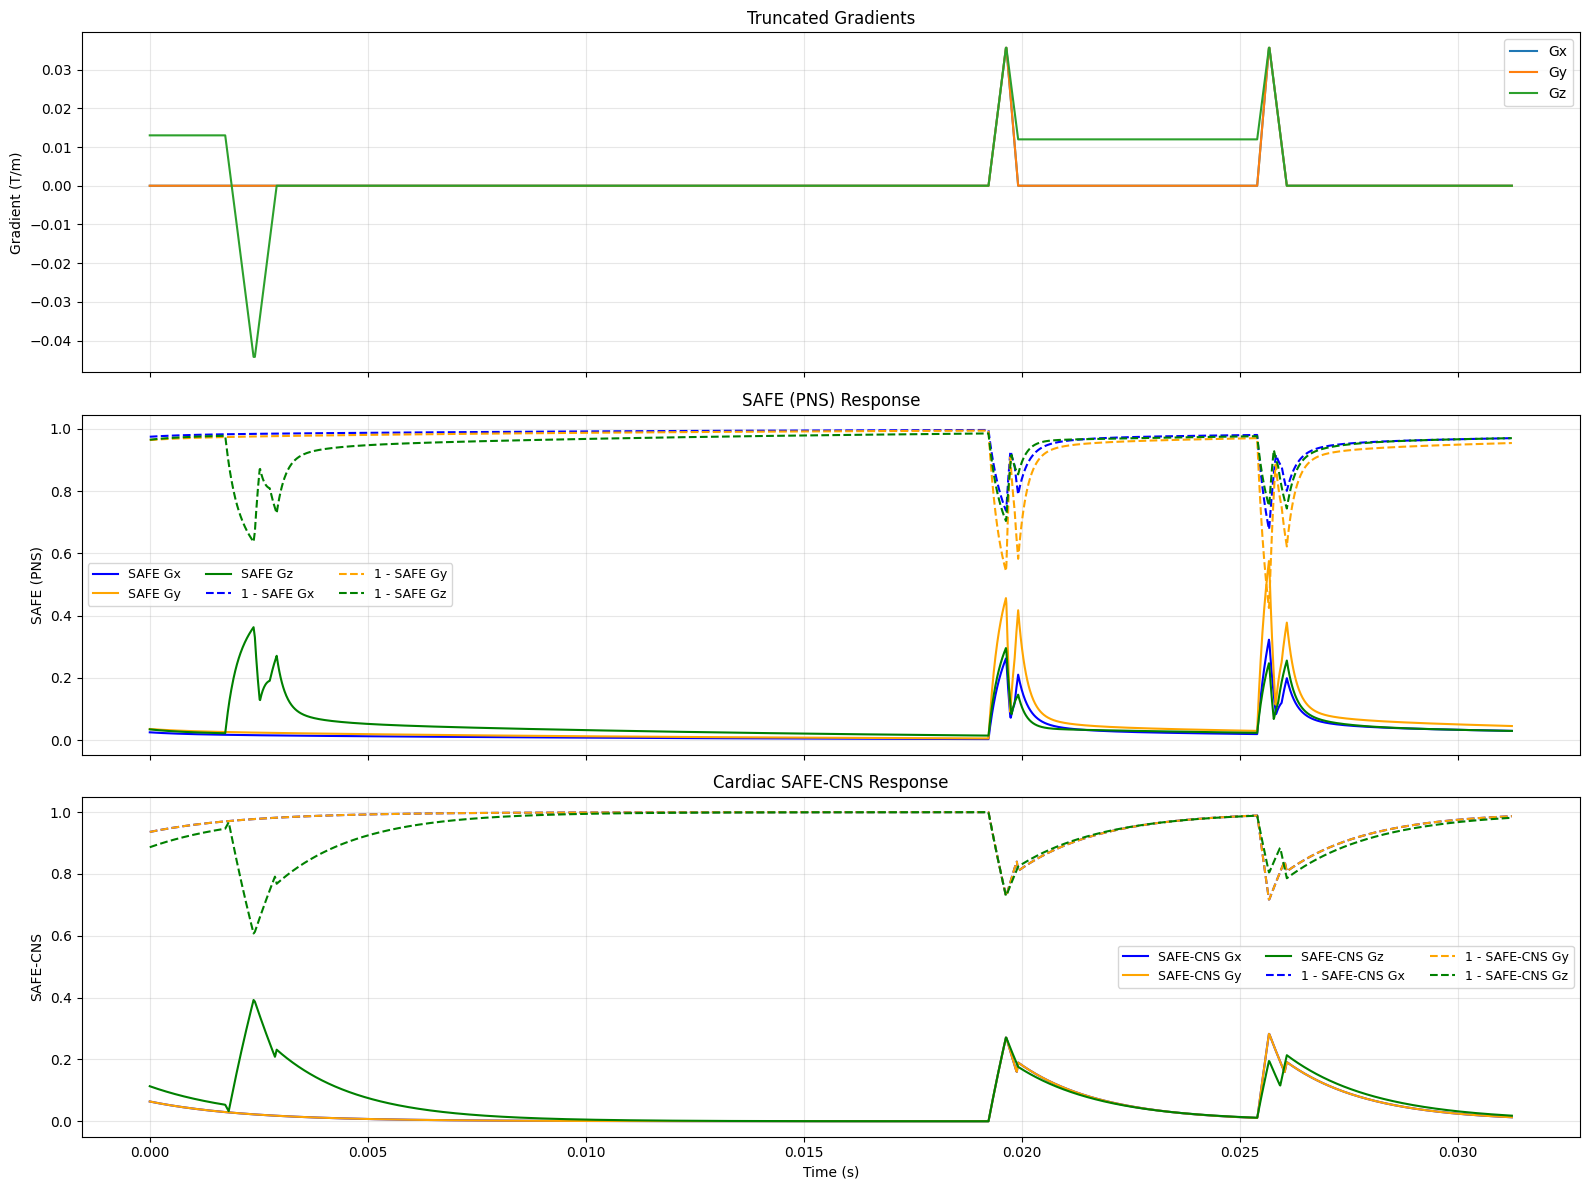

In [15]:

main_path = '../Sequence_Code/'
timing_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls.mat'
waveform_file_name = 'diffusion_timing_parameters_Gmax200_slr-ls_waveforms.mat'

seq = PNSCNS_SequenceBuilder(
    timing_file=os.path.join(main_path, timing_file_name),
    waveform_file=os.path.join(main_path, waveform_file_name),
    dt_in=1e-5,
    dt_out=200e-6,
    safe_params=safe_params,
    safe_params_cardiac=safe_params_cardiac,
    TE=0.045,
    n_repeats=5
)

# Access outputs
Gx_final = seq.Gx_out
safe_final = seq.safe_gx_out
cns_final  = seq.safe_cardiac_gx_out
t_out      = seq.t_out

# Plot
seq.plot_all()



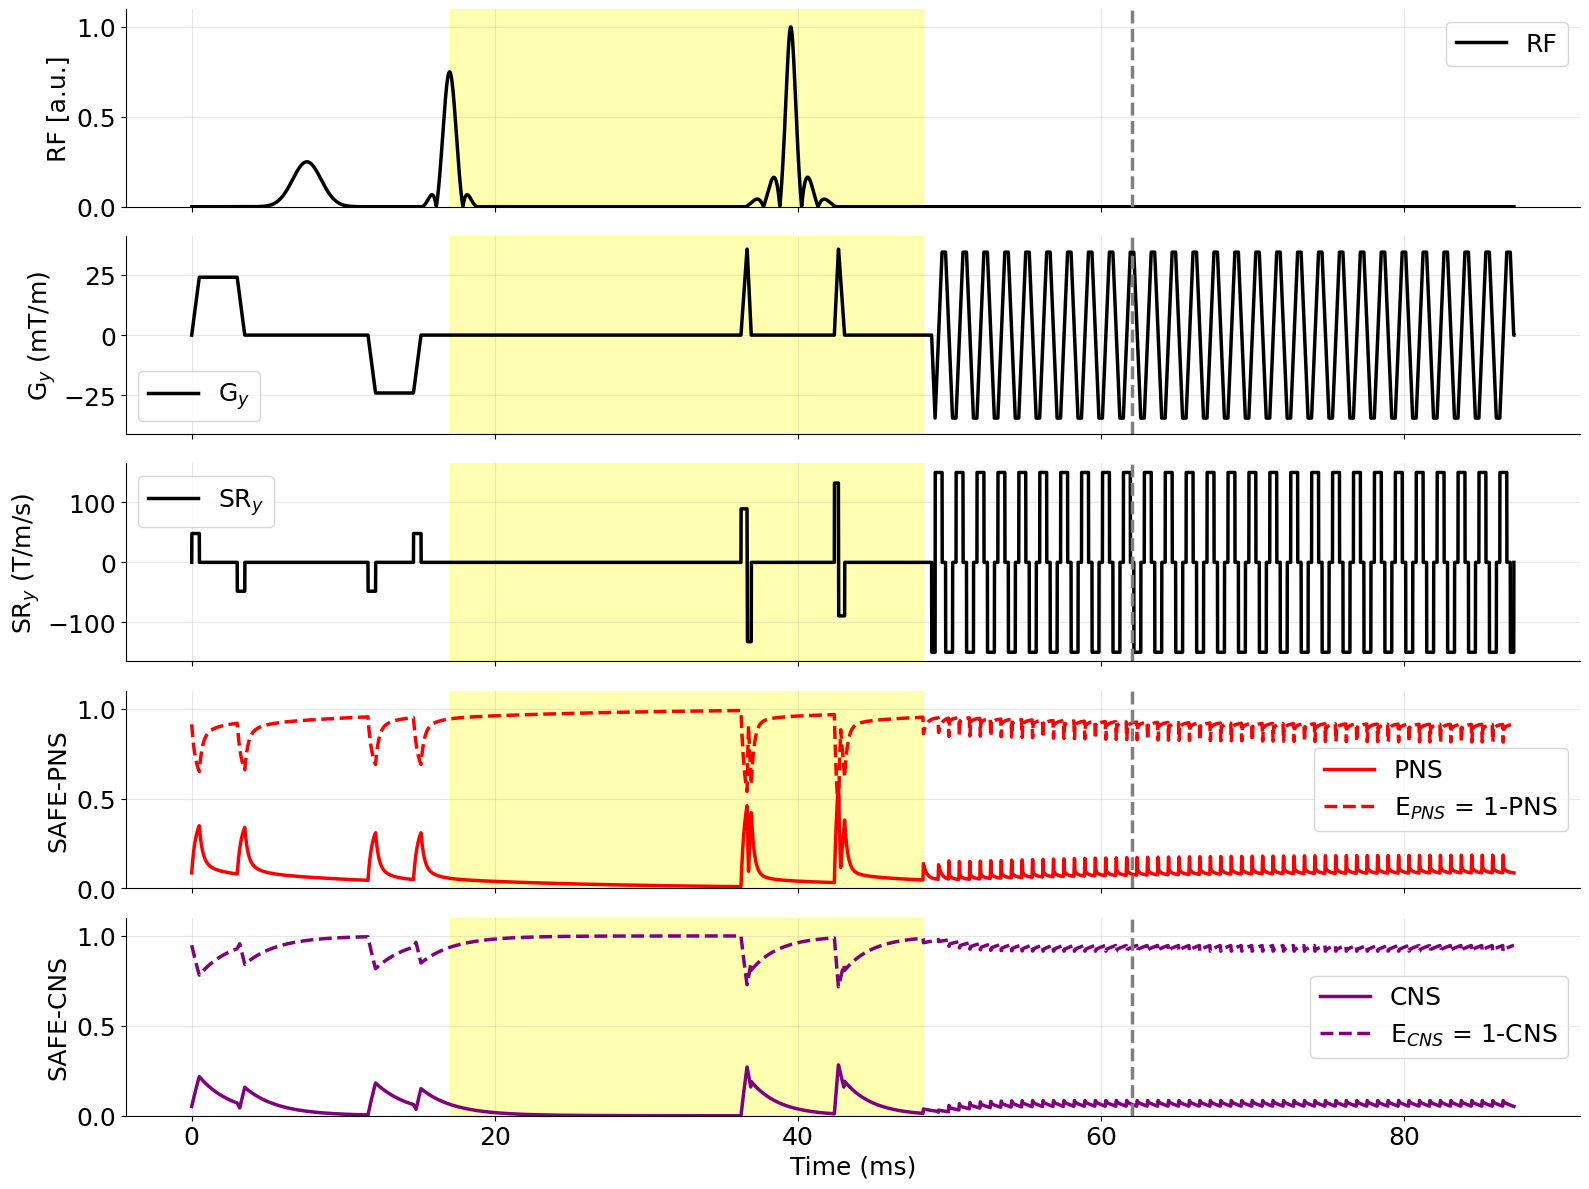

TE is 45.0 ms


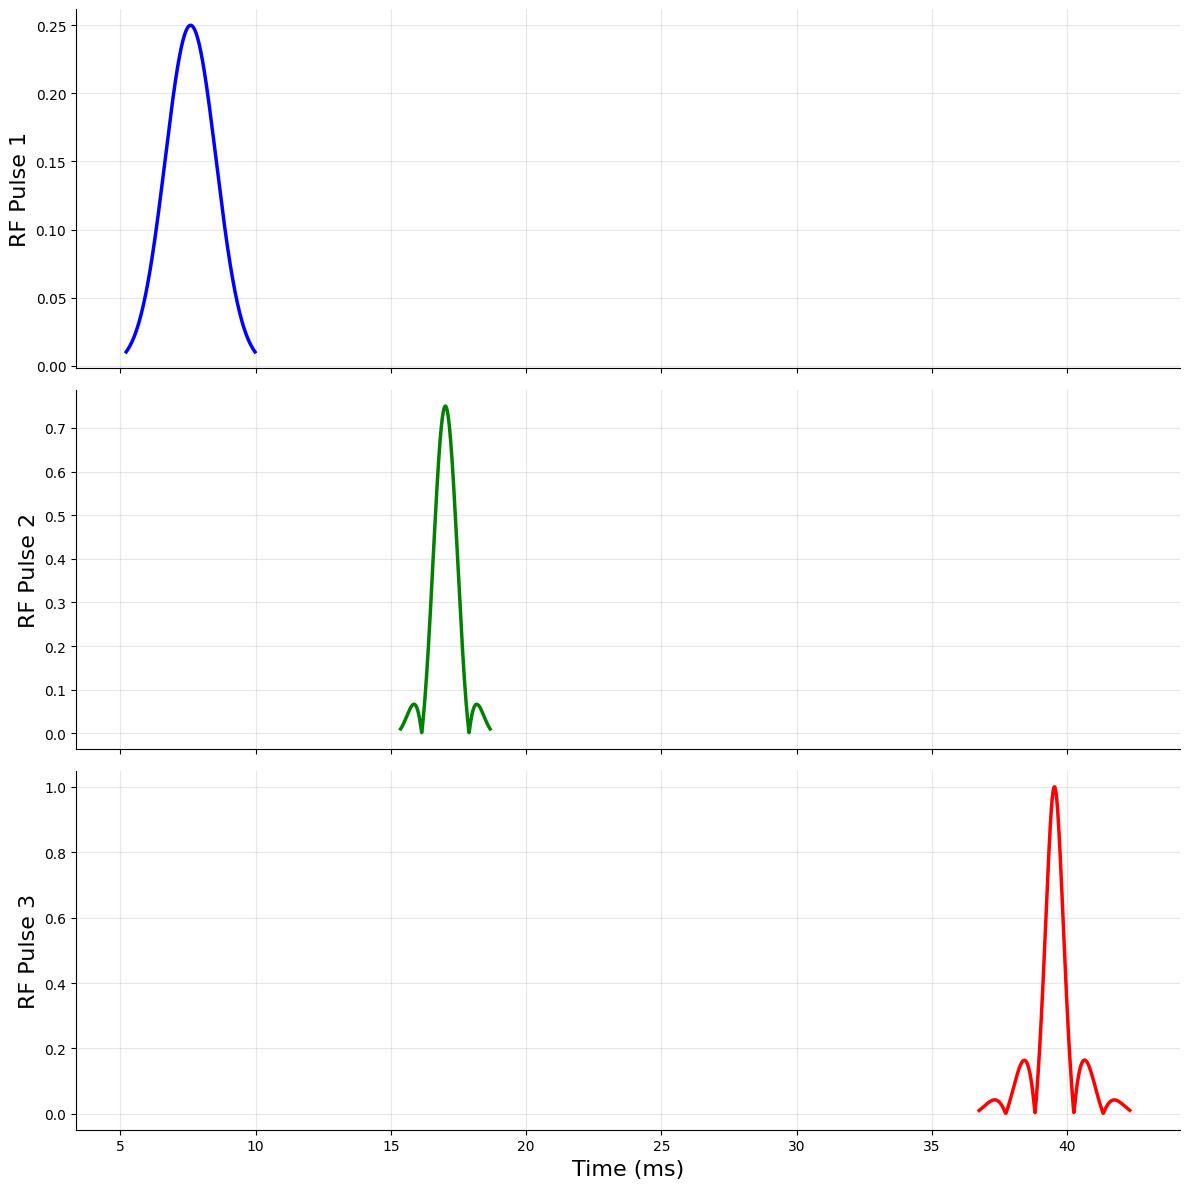

In [16]:
seq.plot_5th_repetition()
seq.plot_separate_sinc_RF_pulses(min_gap_pts=10, lw = 2.5)

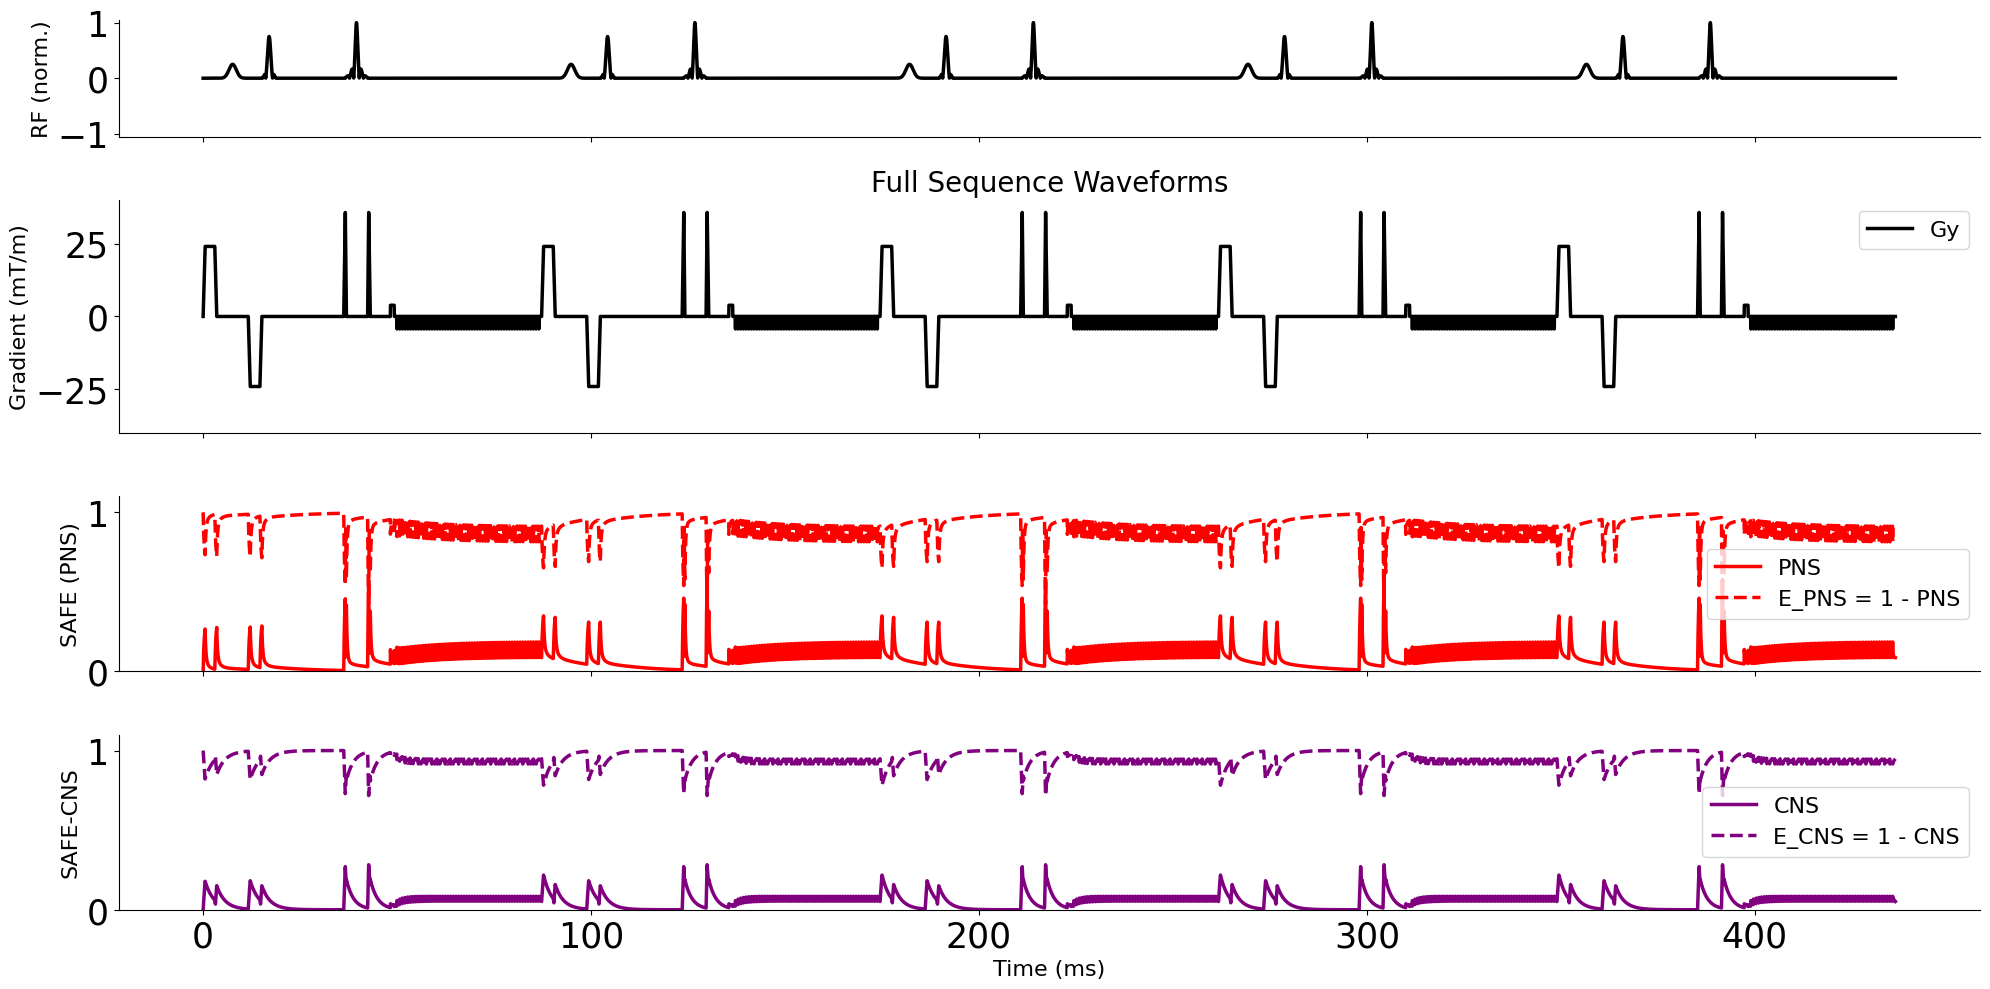

In [17]:
seq.plot_full_sequence(lw = 2.5)

In [18]:
seq.save_epi_block(waveform_file_name.split('.mat')[0] + '_epi_only.npz')

Saved EPI block → diffusion_timing_parameters_Gmax200_slr-ls_waveforms_epi_only.npz


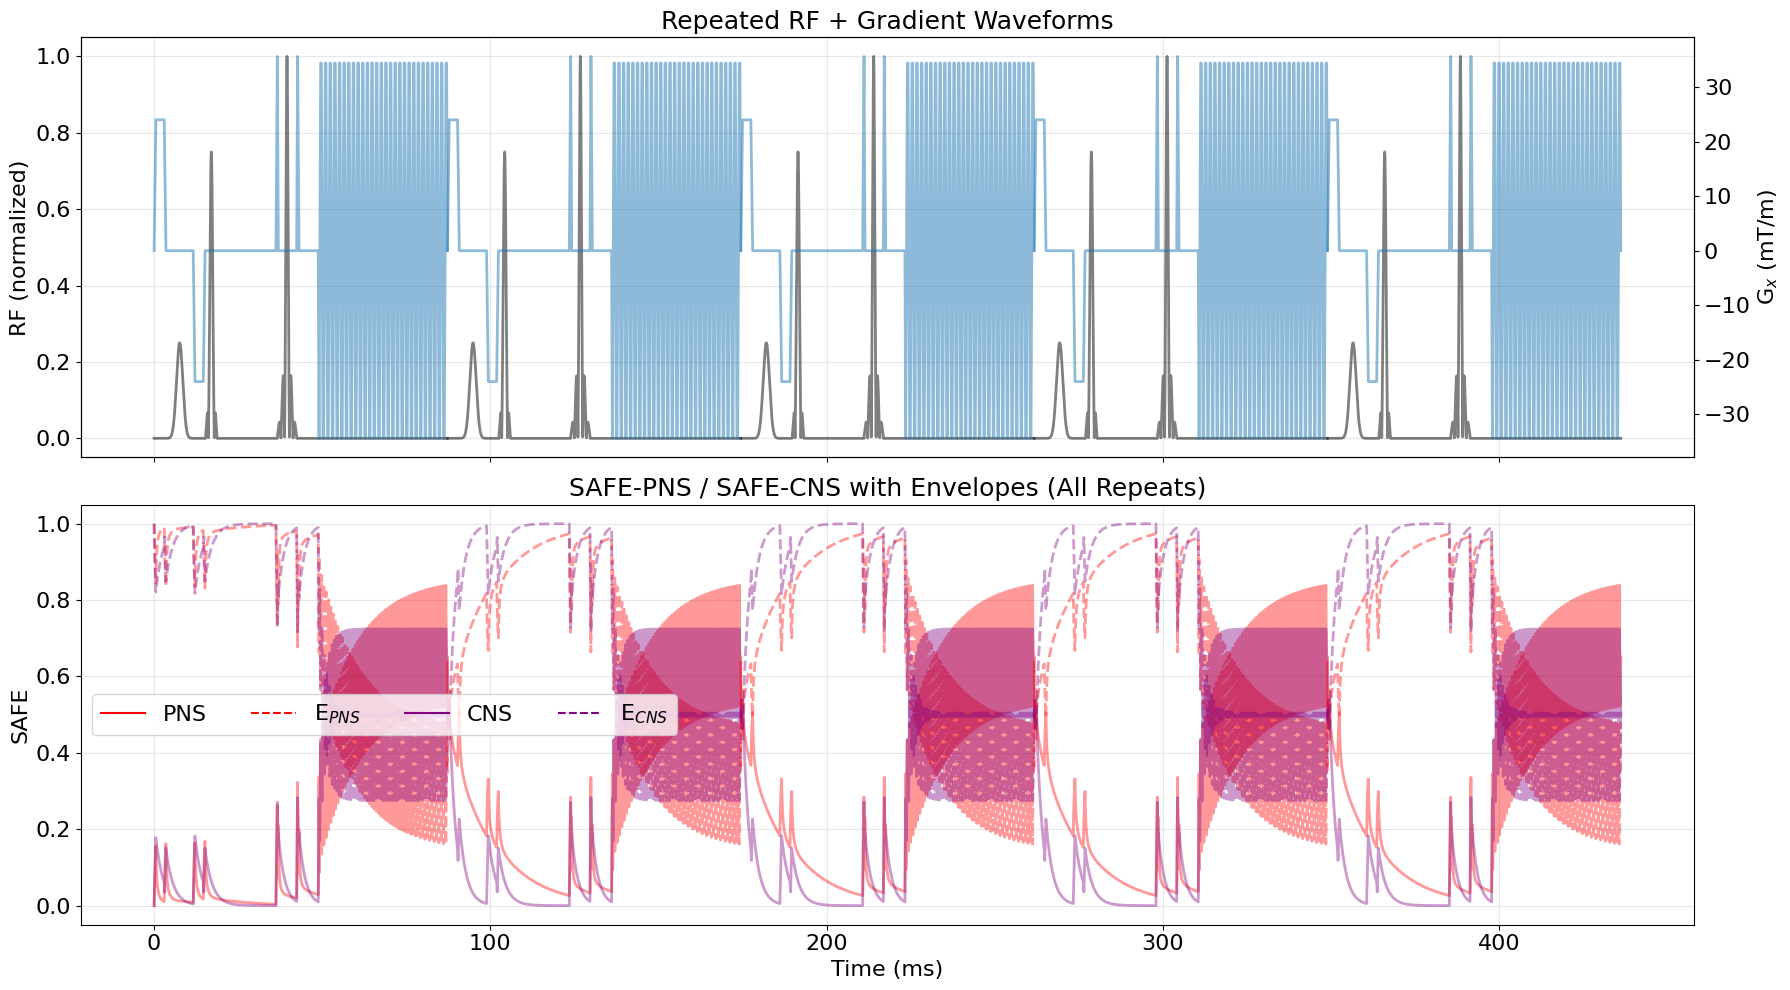

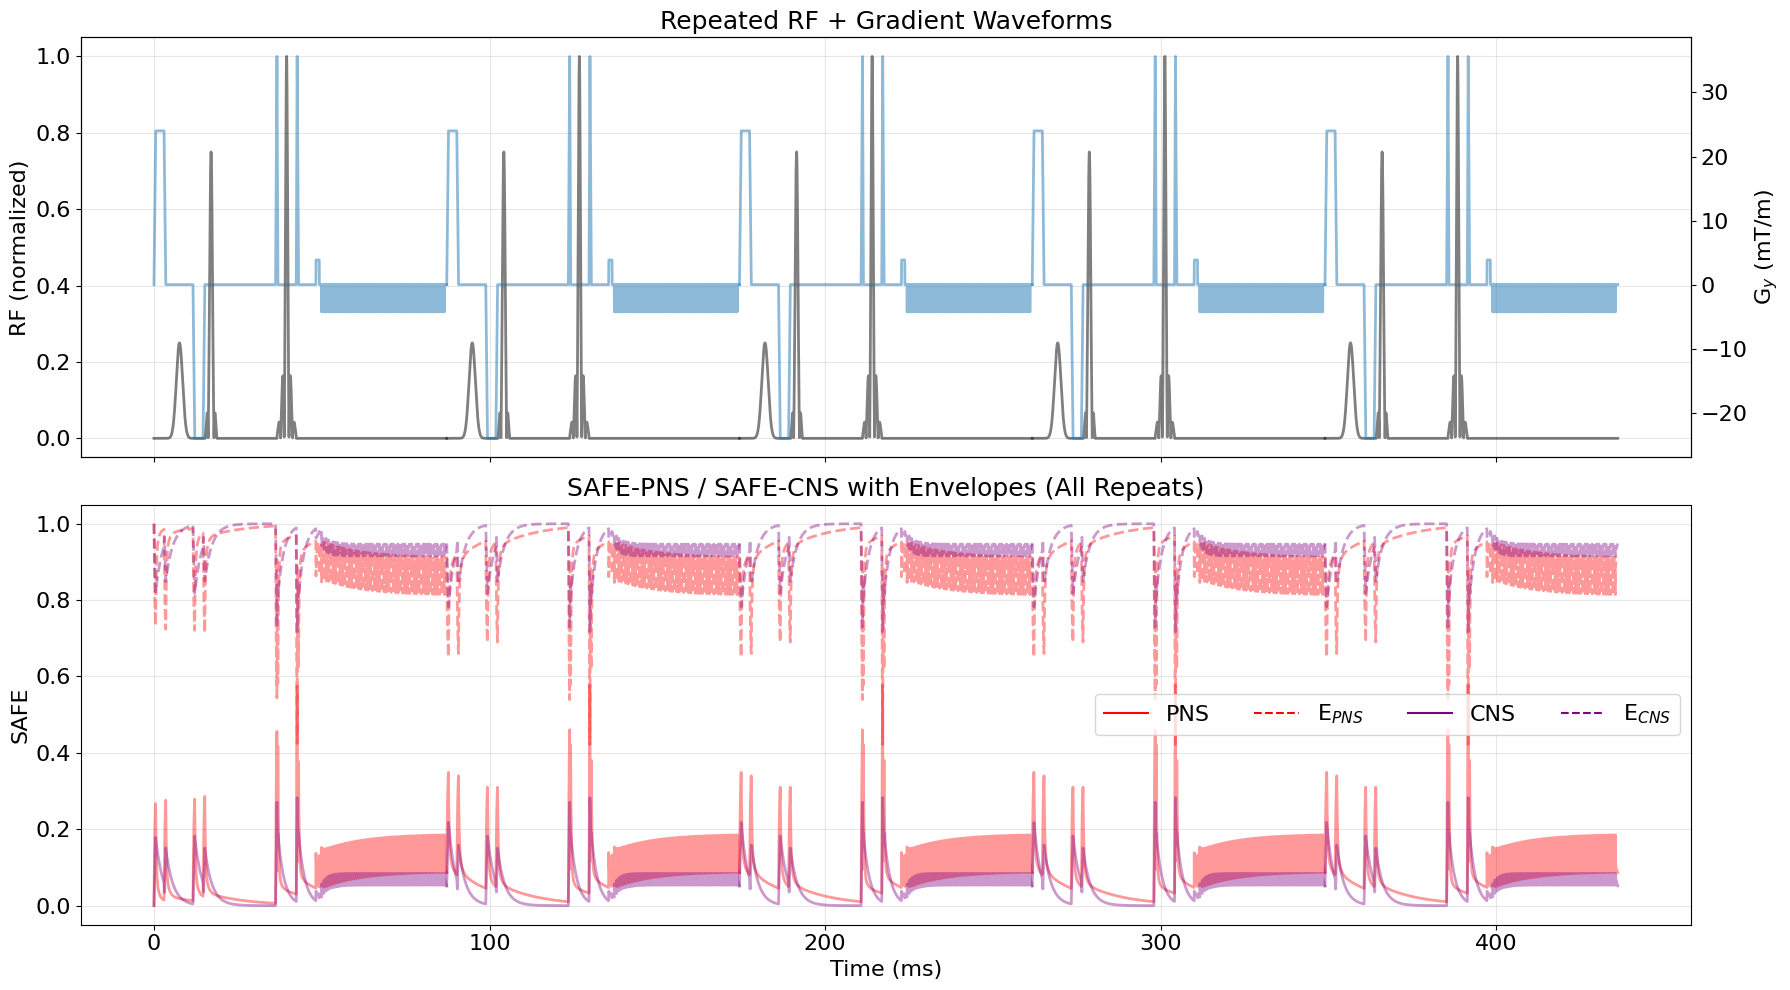

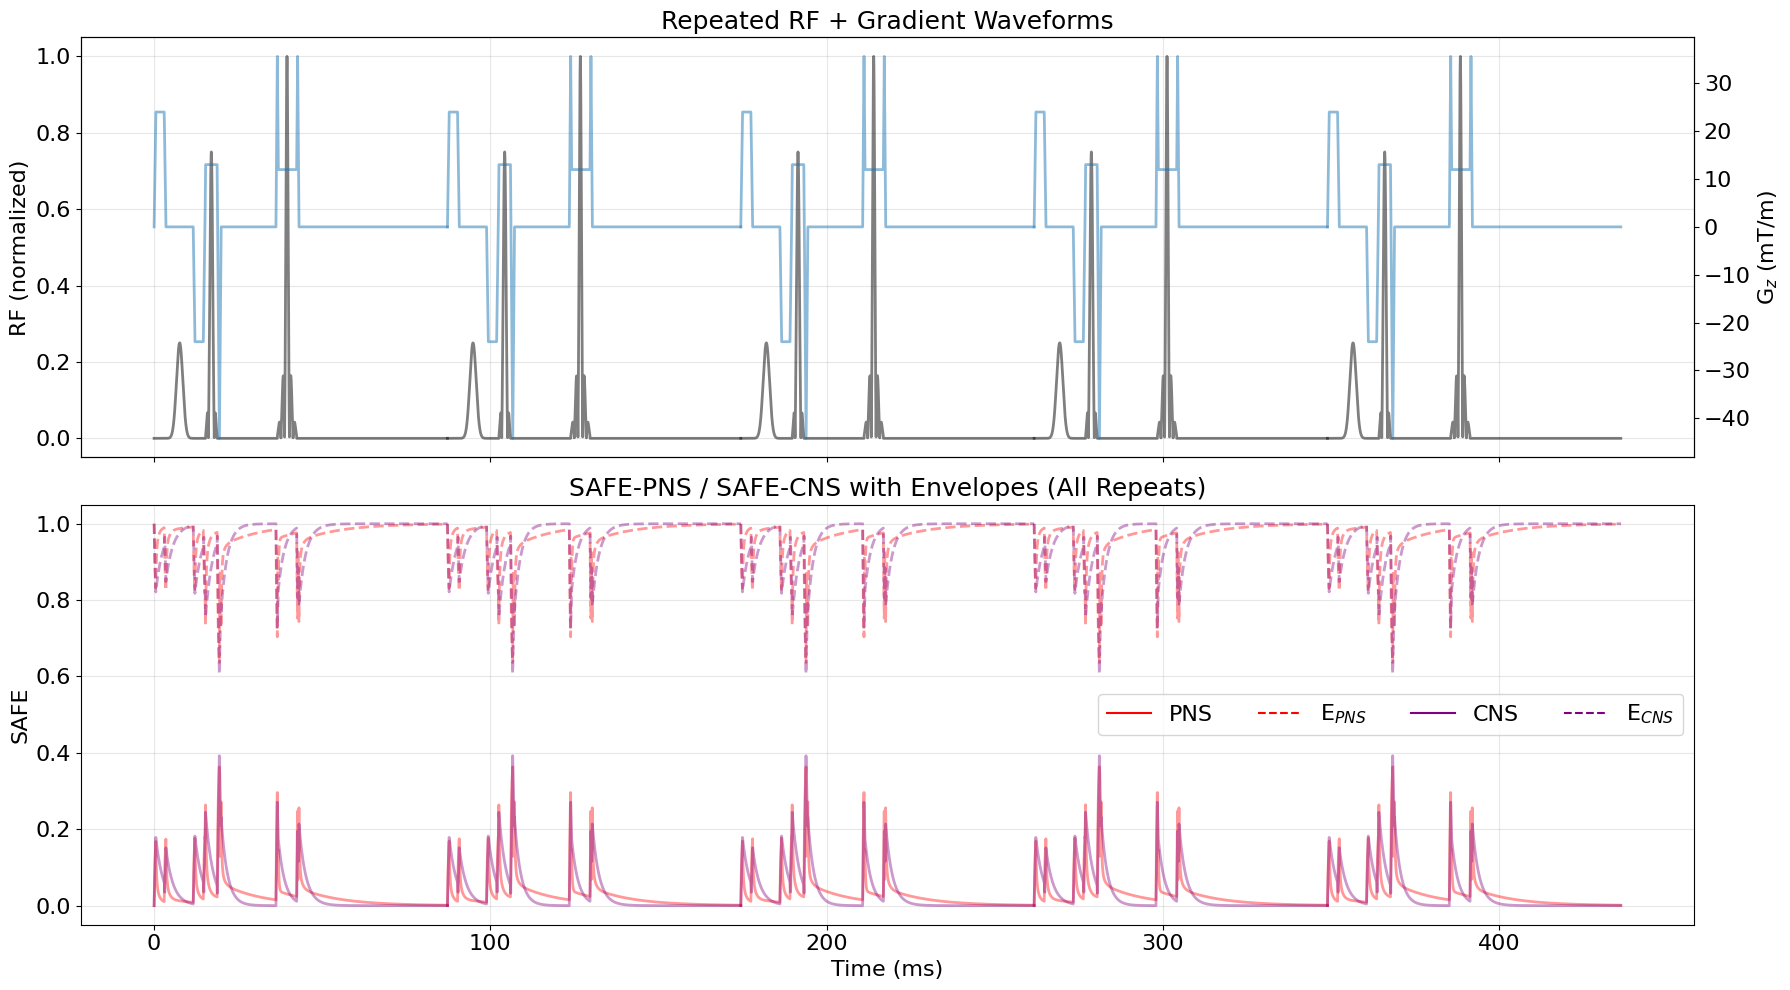

In [19]:
seq.plot_repeated_rf_grad_and_safe(grad_axis='x')
seq.plot_repeated_rf_grad_and_safe(grad_axis='y')
seq.plot_repeated_rf_grad_and_safe(grad_axis='z')